## README

Author: Enguang Fu

Custom script to map raw PacBio cDNA HiFi reads of long-read transcripts to ref genome.

Input:
- Demultiplexed cDNA HiFi reads (PacBio Iso-seq)
<!-- - Consensus RNA isoforms in .fasta file; sequences in 5' to 3' polarity -->
- Genome of organisim in .genbank file e.g. JCVI-Syn1

Output:
- Binary Alignment Map (BAM) file after QC

Steps:
- 00: Analyze PacBio cDNA HiFi reads to get full-length non-concatermer reads (FLNC)
- 01: Map FLNC onto genome for BAM
- 02: Quality control


In [54]:
import os

HOME_DIR = "/data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics"
WORK_DIR = os.path.join(HOME_DIR, "PacBio_Processing")

INTERMEDIATE_DIR = os.path.join(WORK_DIR, "intermediate_files")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

## Analyze cDNA HiFi reads to get FLNC reads

Input: Demultiplexed cDNA HiFi reads  
Output: FLNC
- Primer removed with strandness identified
- Poly(A)/(T) trimmed

Via the enrichment analysis of 5' and 3' ends of the merged demultiplexed raw reads, I found out at the 5' ends
- Handle for oligo-dT primer is 5' TAAGCAGTGGTATCAACGCAGAGTAC + TTTTTT... 3' in half of the reads.
- Possible remaining barcodes as TGCAATGAAGTCGCAGGGTTGGG + non-fix seqs in the other half.

At the 3' ends, is the reverse complement.
  
To summarize for double-stranded cDNA HiFi reads we have both strands:  
For antisense-strand cDNA: 5' TAAGCAGTGGTATCAACGCAGAGTAC + TTTTTT... + reverse-complement of RNA body + CCCAACCCTGCGACTTCATTGCA  
For sense-strand cDNA: 5' TGCAATGAAGTCGCAGGGTTGGG + RNA body + ...AAAAAA +  GTACTCTGCGTTGATACCACTGCTTA

### Reverse-complement the cDNA correponding to the anti-sense strand

Filter out the reads not with complete H1/H2, and BC/BCRC

In [43]:
H1="TAAGCAGTGGTATCAACGCAGAGTAC" # 26 nt, on antisense strand 5' end # oligo-dT primer
H2="GTACTCTGCGTTGATACCACTGCTTA" # on sense-strand 3' end
BC="TGCAATGAAGTCGCAGGGTTGGG" # 23 nt on sense strand 5' end # barcode
BCRC="CCCAACCCTGCGACTTCATTGCA" # on antisense-strand 3' end

In [44]:
# =========================
# pigz-stream FASTQ module
# + progress reporting
# =========================

from __future__ import annotations

import io
import sys
import time
import subprocess
from contextlib import contextmanager
from dataclasses import dataclass
from typing import Iterator, Optional, Tuple


@contextmanager
def pigz_reader(path: str, threads: int = 16, bufsize: int = 1024 * 1024):
    """
    Yields a BufferedReader providing decompressed bytes from `path` via pigz -dc.
    """
    p = subprocess.Popen(
        ["pigz", "-dc", "-p", str(threads), path],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        bufsize=0,
    )
    if p.stdout is None or p.stderr is None:
        if p.stdout: p.stdout.close()
        if p.stderr: p.stderr.close()
        p.kill()
        raise RuntimeError("Failed to start pigz_reader subprocess")

    try:
        yield io.BufferedReader(p.stdout, buffer_size=bufsize)
    finally:
        # Close stdout so pigz can get SIGPIPE/EOF semantics cleanly if needed
        try:
            p.stdout.close()
        except Exception:
            pass

        # Collect stderr after process ends
        err = b""
        try:
            # Wait first to ensure pigz terminates; then read stderr
            rc = p.wait()
            err = p.stderr.read() or b""
        finally:
            try:
                p.stderr.close()
            except Exception:
                pass

        if rc != 0:
            msg = err.decode("utf-8", errors="replace")
            raise RuntimeError(f"pigz_reader failed (code={rc}):\n{msg}")


@contextmanager
def pigz_writer(
    path: str,
    threads: int = 16,
    bufsize: int = 1024 * 1024,
    compresslevel: int = 6,
):
    """
    Yields a BufferedWriter accepting uncompressed bytes and writing gz to `path`
    via pigz (stdout redirected to file).
    """
    out_f = open(path, "wb")
    p = subprocess.Popen(
        ["pigz", "-p", str(threads), f"-{int(compresslevel)}"],
        stdin=subprocess.PIPE,
        stdout=out_f,
        stderr=subprocess.PIPE,
        bufsize=0,
    )
    if p.stdin is None or p.stderr is None:
        out_f.close()
        if p.stdin: p.stdin.close()
        if p.stderr: p.stderr.close()
        p.kill()
        raise RuntimeError("Failed to start pigz_writer subprocess")

    writer = io.BufferedWriter(p.stdin, buffer_size=bufsize)

    try:
        yield writer
    finally:
        # Flush our BufferedWriter (this flushes into pigz stdin)
        try:
            writer.flush()
        except BrokenPipeError:
            # pigz may have exited early (e.g., downstream failure)
            pass

        # Close stdin to signal EOF to pigz
        try:
            writer.close()  # closes p.stdin as well
        except Exception:
            pass

        # Close output file handle (pigz writes to it)
        try:
            out_f.flush()
        except Exception:
            pass
        out_f.close()

        # Wait for pigz and then read stderr
        err = b""
        try:
            rc = p.wait()
            err = p.stderr.read() or b""
        finally:
            try:
                p.stderr.close()
            except Exception:
                pass

        if rc != 0:
            msg = err.decode("utf-8", errors="replace")
            raise RuntimeError(f"pigz_writer failed (code={rc}):\n{msg}")


# -------------------------
# FASTQ orientation logic
# -------------------------
_RC_TABLE = bytes.maketrans(b"ACGTNacgtn", b"TGCANtgcan")

def revcomp(seq: bytes) -> bytes:
    return seq.translate(_RC_TABLE)[::-1]


@dataclass
class Progress:
    enabled: bool = True
    every_seconds: float = 5.0          # report interval
    label: str = "orient"
    stream = sys.stderr

    # internal state
    _t0: float = 0.0
    _t_last: float = 0.0
    _n_last: int = 0

    def start(self, n0: int = 0) -> None:
        now = time.time()
        self._t0 = now
        self._t_last = now
        self._n_last = n0

    def maybe_report(self, n: int, written: int, h1_flips: int, bc_flips: int, filtered: int) -> None:
        if not self.enabled:
            return
        now = time.time()
        if (now - self._t_last) < self.every_seconds:
            return

        dt = now - self._t_last
        dn = n - self._n_last
        rate = (dn / dt) if dt > 0 else 0.0

        total_dt = now - self._t0
        total_rate = (n / total_dt) if total_dt > 0 else 0.0

        print(
            f"[{self.label}] reads={n:,}  written={written:,}  "
            f"h1_flips={h1_flips:,}  bc_flips={bc_flips:,}  "
            f"filtered={filtered:,}  "
            f"rate={rate:,.0f} r/s  avg={total_rate:,.0f} r/s",
            file=self.stream,
            flush=True,
        )
        self._t_last = now
        self._n_last = n

    def final(self, n: int, written: int, h1_flips: int, bc_flips: int, filtered: int) -> None:
        if not self.enabled:
            return
        now = time.time()
        total_dt = now - self._t0
        total_rate = (n / total_dt) if total_dt > 0 else 0.0
        print(
            f"[{self.label}] DONE  reads={n:,}  written={written:,}  "
            f"h1_flips={h1_flips:,}  bc_flips={bc_flips:,}  "
            f"filtered={filtered:,}  "
            f"elapsed={total_dt:,.1f}s  avg={total_rate:,.0f} r/s",
            file=self.stream,
            flush=True,
        )


def orient_fastq_stream(
    fin: io.BufferedReader,
    fout: io.BufferedWriter,
    *,
    H1: bytes,
    BCRC: bytes,
    W: int = 80,
    flush_every: int = 5000,
    progress: Optional[Progress] = None,
) -> Tuple[int, int, int, int]:
    """
    FASTQ stream processing (assumes 4-line FASTQ records: header/seq/+ /qual).
    - If H1 found in beginning W bases: antisense-strand
    - Else if seq ends with BCRC: antisense-strand
    - Else keep orientation
    - Filter: keep only reads whose oriented seq ends with 10As + revcomp(H1)

    Returns (total_records, h1_flips, bc_flips, filtered_out).
    """

    required_suffix = (b"A" * 10) + revcomp(H1) # poly(A) tail + rev(H1), which is H2

    total = h1_flips = bc_flips = filtered_out = 0
    written = 0

    # local bindings for speed
    readline = fin.readline
    write = fout.write
    join = b"".join
    buf = []
    append = buf.append

    if progress is None:
        progress = Progress(enabled=False)
    progress.start(0)

    while True:
        header = readline()
        if not header:
            break
        seq = readline()
        plus = readline()
        qual = readline()

        if not qual:
            break  # truncated record at EOF

        total += 1

        # Strip line endings; rstrip(b"\r\n") is correct and reasonably fast
        header = header.rstrip(b"\r\n")
        seq    = seq.rstrip(b"\r\n")
        plus   = plus.rstrip(b"\r\n")
        qual   = qual.rstrip(b"\r\n")

        head = seq[:W] if len(seq) > W else seq

        if head.find(H1) != -1:
            s2 = revcomp(seq)
            q2 = qual[::-1]
            h1_flips += 1
        elif seq.endswith(BCRC):
            s2 = revcomp(seq)
            q2 = qual[::-1]
            bc_flips += 1
        else:
            s2 = seq
            q2 = qual

        if len(s2) != len(q2):
            m = len(s2) if len(s2) < len(q2) else len(q2)
            s2 = s2[:m]
            q2 = q2[:m]

        if not s2.endswith(required_suffix):
            filtered_out += 1
            # progress update still based on total reads processed
            progress.maybe_report(total, written, h1_flips, bc_flips, filtered_out)
            continue

        # FASTQ write (keep header/plus as-is)
        append(header + b"\n")
        append(s2 + b"\n")
        append(plus + b"\n")
        append(q2 + b"\n")
        written += 1

        # flush in chunks
        if total % flush_every == 0 and buf:
            write(join(buf))
            buf.clear()

        progress.maybe_report(total, written, h1_flips, bc_flips, filtered_out)

    if buf:
        write(join(buf))

    progress.final(total, written, h1_flips, bc_flips, filtered_out)
    return total, h1_flips, bc_flips, filtered_out


def orient_fastq_pigz(
    in_gz: str,
    out_gz: str,
    *,
    H1: str,
    BCRC: str,
    W: int = 80,
    threads_in: int = 16,
    threads_out: int = 16,
    compresslevel: int = 6,
    progress_every_seconds: float = 5.0,
) -> Tuple[int, int, int, int]:
    """
    End-to-end helper for notebooks:
      reads input.fastq.gz via pigz -dc
      processes records in Python
      writes output.fastq.gz via pigz

    Returns (total_records, h1_flips, bc_flips, filtered_out).
    """
    prog = Progress(enabled=True, every_seconds=progress_every_seconds, label="orient")

    with pigz_reader(in_gz, threads=threads_in) as fin, \
         pigz_writer(out_gz, threads=threads_out, compresslevel=compresslevel) as fout:
        return orient_fastq_stream(
            fin,
            fout,
            H1=H1.encode("ascii"),
            BCRC=BCRC.encode("ascii"),
            W=W,
            progress=prog,
        )

In [ ]:
import os

merged_all_seqs = os.path.join(HOME_DIR, "PacBio_Raw/merged.hifi_reads.fastq.gz")

# unoriented_fastq = "./sub.fastq.gz"
unoriented_fastq = merged_all_seqs
oriented_fastq = os.path.join(INTERMEDIATE_DIR, "all.oriented.fastq.gz")

# =========================
# Example usage in notebook
# =========================


total, h1_flips, bc_flips, filtered = orient_fastq_pigz(
    unoriented_fastq,
    oriented_fastq,
    H1=H1,  # <-- set this,
	BCRC=BCRC,
    W=80,
    threads_in=16,
    threads_out=16,
    compresslevel=6,     # set 1 if you want faster, larger output
    progress_every_seconds=5.0,
)
print(total, h1_flips, bc_flips, filtered)


[orient] reads=254,230  written=229,023  h1_flips=114,835  bc_flips=19,993  filtered=25,207  rate=50,846 r/s  avg=50,846 r/s
[orient] reads=500,000  written=450,521  h1_flips=225,303  bc_flips=39,119  filtered=49,479  rate=48,836 r/s  avg=49,837 r/s
[orient] reads=750,000  written=675,688  h1_flips=337,907  bc_flips=58,779  filtered=74,312  rate=49,904 r/s  avg=49,860 r/s
[orient] reads=1,005,000  written=906,240  h1_flips=453,771  bc_flips=77,834  filtered=98,760  rate=50,859 r/s  avg=50,110 r/s
[orient] reads=1,247,613  written=1,128,473  h1_flips=564,601  bc_flips=92,976  filtered=119,140  rate=48,522 r/s  avg=49,793 r/s
[orient] reads=1,482,170  written=1,342,899  h1_flips=671,694  bc_flips=107,830  filtered=139,271  rate=46,911 r/s  avg=49,313 r/s
[orient] reads=1,725,000  written=1,564,898  h1_flips=782,507  bc_flips=123,403  filtered=160,102  rate=48,285 r/s  avg=49,166 r/s
[orient] reads=1,980,000  written=1,798,876  h1_flips=899,818  bc_flips=138,792  filtered=181,124  rate=50

2949889 1346816 191441 255417


### Remove primers and optionally barcodes

In [47]:
from __future__ import annotations

import io
import sys
import time
import subprocess
from contextlib import contextmanager
from dataclasses import dataclass
from typing import Optional, Tuple


# -------------------------
# pigz stream helpers
# -------------------------
@contextmanager
def pigz_reader(path: str, threads: int = 16, bufsize: int = 1024 * 1024):
    p = subprocess.Popen(
        ["pigz", "-dc", "-p", str(threads), path],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        bufsize=0,
    )
    if p.stdout is None or p.stderr is None:
        if p.stdout: p.stdout.close()
        if p.stderr: p.stderr.close()
        p.kill()
        raise RuntimeError("Failed to start pigz_reader subprocess")

    try:
        yield io.BufferedReader(p.stdout, buffer_size=bufsize)
    finally:
        try:
            p.stdout.close()
        except Exception:
            pass

        err = b""
        try:
            rc = p.wait()
            err = p.stderr.read() or b""
        finally:
            try:
                p.stderr.close()
            except Exception:
                pass

        if rc != 0:
            msg = err.decode("utf-8", errors="replace")
            raise RuntimeError(f"pigz_reader failed (code={rc}):\n{msg}")


@contextmanager
def pigz_writer(
    path: str,
    threads: int = 16,
    bufsize: int = 1024 * 1024,
    compresslevel: int = 6,
):
    out_f = open(path, "wb")
    p = subprocess.Popen(
        ["pigz", "-p", str(threads), f"-{int(compresslevel)}"],
        stdin=subprocess.PIPE,
        stdout=out_f,
        stderr=subprocess.PIPE,
        bufsize=0,
    )
    if p.stdin is None or p.stderr is None:
        out_f.close()
        if p.stdin: p.stdin.close()
        if p.stderr: p.stderr.close()
        p.kill()
        raise RuntimeError("Failed to start pigz_writer subprocess")

    writer = io.BufferedWriter(p.stdin, buffer_size=bufsize)

    try:
        yield writer
    finally:
        try:
            writer.flush()
        except BrokenPipeError:
            pass

        try:
            writer.close()  # closes pigz stdin
        except Exception:
            pass

        try:
            out_f.flush()
        except Exception:
            pass
        out_f.close()

        err = b""
        try:
            rc = p.wait()
            err = p.stderr.read() or b""
        finally:
            try:
                p.stderr.close()
            except Exception:
                pass

        if rc != 0:
            msg = err.decode("utf-8", errors="replace")
            raise RuntimeError(f"pigz_writer failed (code={rc}):\n{msg}")


# -------------------------
# progress reporting
# -------------------------
@dataclass
class Progress:
    enabled: bool = True
    every_seconds: float = 5.0
    label: str = "trim"
    stream = sys.stderr

    _t0: float = 0.0
    _t_last: float = 0.0
    _n_last: int = 0

    def start(self, n0: int = 0) -> None:
        now = time.time()
        self._t0 = now
        self._t_last = now
        self._n_last = n0

    def maybe_report(self, n: int, written: int, h1_trim: int, bcrc_trim: int, dropped: int) -> None:
        if not self.enabled:
            return
        now = time.time()
        if (now - self._t_last) < self.every_seconds:
            return

        dt = now - self._t_last
        dn = n - self._n_last
        rate = (dn / dt) if dt > 0 else 0.0

        total_dt = now - self._t0
        avg = (n / total_dt) if total_dt > 0 else 0.0

        print(
            f"[{self.label}] reads={n:,}  written={written:,}  "
            f"h1_trim={h1_trim:,}  bcrc_trim={bcrc_trim:,}  dropped={dropped:,}  "
            f"rate={rate:,.0f} r/s  avg={avg:,.0f} r/s",
            file=self.stream,
            flush=True,
        )
        self._t_last = now
        self._n_last = n

    def final(self, n: int, written: int, h1_trim: int, bcrc_trim: int, dropped: int) -> None:
        if not self.enabled:
            return
        now = time.time()
        total_dt = now - self._t0
        avg = (n / total_dt) if total_dt > 0 else 0.0
        print(
            f"[{self.label}] DONE  reads={n:,}  written={written:,}  "
            f"h1_trim={h1_trim:,}  bcrc_trim={bcrc_trim:,}  dropped={dropped:,}  "
            f"elapsed={total_dt:,.1f}s  avg={avg:,.0f} r/s",
            file=self.stream,
            flush=True,
        )


# -------------------------
# mismatch helpers (bytes)
# -------------------------
def count_mismatches(a: bytes, b: bytes) -> int:
    # a and b must have equal length; loop in Python is OK because overlap is small (<= primer len)
    mism = 0
    for x, y in zip(a, b):
        if x != y:
            mism += 1
    return mism


def trim_front_primer_bytes(
    seq: bytes,
    qual: bytes,
    primer: bytes,
    mismatches: int,
    min_overlap: int,
    slack: int = 0,
) -> Tuple[bytes, bytes, bool]:
    """
    Try to trim a 5' primer by allowing up to `mismatches` mismatches.
    Searches only within the first (min_overlap + slack) bases (same intent as original code).
    Returns (trimmed_seq, trimmed_qual, did_trim).
    """
    # Fast exits
    if len(seq) < min_overlap:
        return seq, qual, False

    # Search window
    w = min(len(seq), len(primer)+slack)
    seq5 = seq[:w]

    max_i = min(len(primer), len(seq5))

    # Try decreasing overlap from w down to min_overlap
    for i in range(max_i, min_overlap - 1, -1):
        # Compare seq5[:i] vs primer[:i]
        if count_mismatches(seq5[:i], primer[:i]) <= mismatches:
            return seq[i:], qual[i:], True

    return seq, qual, False


def trim_tail_primer_bytes(
    seq: bytes,
    qual: bytes,
    primer: bytes,
    mismatches: int,
    min_overlap: int,
    slack: int = 0,
) -> Tuple[bytes, bytes, bool]:
    """
    Try to trim a 3' primer by allowing up to `mismatches` mismatches.
    Searches only within the last (len(primer) + slack) bases (same intent as original code).
    Returns (trimmed_seq, trimmed_qual, did_trim).
    """
    if len(seq) < min_overlap:
        return seq, qual, False

    # Window at 3'
    w = min(len(seq), len(primer) + slack)
    seq3 = seq[-w:]

    # Overlap length cannot exceed both primer and window lengths
    max_i = min(len(primer), len(seq3))

    for i in range(max_i, min_overlap - 1, -1):
        # Compare last i bases of seq3 vs last i bases of primer
        if count_mismatches(seq3[-i:], primer[-i:]) <= mismatches:
            return seq[:-i], qual[:-i], True

    return seq, qual, False


# -------------------------
# FASTQ trimming (stream)
# -------------------------
def trim_primers_stream(
    fin: io.BufferedReader,
    fout: io.BufferedWriter,
    *,
    H2: bytes,
    BC: bytes,
    min_len: int = 10,
    min_overlap: int = 18,
    h2_mismatches: int = 3,
    bc_mismatches: int = 3,
    flush_every: int = 5000,
    progress: Optional[Progress] = None,
) -> Tuple[int, int]:
    """
    FASTQ stream processing (assumes 4-line records).
    Returns (count_in, count_out).
    """
    count_in = count_out = 0
    h2_trimmed = bc_trimmed = dropped = 0

    readline = fin.readline
    write = fout.write
    join = b"".join
    buf = []
    append = buf.append

    if progress is None:
        progress = Progress(enabled=False)
    progress.start(0)

    while True:
        header = readline()
        if not header:
            break
        seq = readline()
        plus = readline()
        qual = readline()
        if not qual:
            break

        count_in += 1

        header = header.rstrip(b"\r\n")
        seq = seq.rstrip(b"\r\n")
        plus = plus.rstrip(b"\r\n")
        qual = qual.rstrip(b"\r\n")

        # Normalize seq/qual lengths if needed
        if len(seq) != len(qual):
            m = min(len(seq), len(qual))
            seq = seq[:m]
            qual = qual[:m]

        # 1) Trim H2 from 3' end tail
        seq2, qual2, did_h2 = trim_tail_primer_bytes(
            seq, qual, H2, mismatches=h2_mismatches, min_overlap=min_overlap
        )
        if did_h2:
            h2_trimmed += 1
        else:
            dropped += 1
            progress.maybe_report(count_in, count_out, h2_trimmed, bc_trimmed, dropped)
            continue

        # 2) Trim BC from 5' head
        seq3, qual3, did_bc = trim_front_primer_bytes(
            seq2, qual2, BC, mismatches=bc_mismatches, min_overlap=min_overlap
        )
        if did_bc:
            bc_trimmed += 1
        else:
            dropped += 1
            progress.maybe_report(count_in, count_out, h2_trimmed, bc_trimmed, dropped)
            continue

        # 3) Filter by minimum length
        if len(seq3) < min_len:
            dropped += 1
            progress.maybe_report(count_in, count_out, h2_trimmed, bc_trimmed, dropped)
            continue

        append(header + b"\n")
        append(seq3 + b"\n")
        append(plus + b"\n")
        append(qual3 + b"\n")
        count_out += 1

        if count_in % flush_every == 0 and buf:
            write(join(buf))
            buf.clear()

        progress.maybe_report(count_in, count_out, h2_trimmed, bc_trimmed, dropped)

    if buf:
        write(join(buf))

    progress.final(count_in, count_out, h2_trimmed, bc_trimmed, dropped)
    return count_in, count_out


def trim_primers_pigz(
    input_fastq_gz: str,
    output_fastq_gz: str,
    *,
    H2: str,
    BC: str,
    min_len: int = 10,
    min_overlap: int = 18,
    h2_mismatches: int = 3,
    bc_mismatches: int = 3,
    threads_in: int = 16,
    threads_out: int = 16,
    compresslevel: int = 6,
    progress_every_seconds: float = 5.0,
) -> Tuple[int, int]:
    """
    Notebook-friendly end-to-end trimming using pigz streams.
    Returns (count_in, count_out).
    """
    prog = Progress(enabled=True, every_seconds=progress_every_seconds, label="trim")

    with pigz_reader(input_fastq_gz, threads=threads_in) as fin, \
         pigz_writer(output_fastq_gz, threads=threads_out, compresslevel=compresslevel) as fout:
        return trim_primers_stream(
            fin,
            fout,
            H2=H2.encode("ascii"),
            BC=BC.encode("ascii"),
            min_len=min_len,
            min_overlap=min_overlap,
            h2_mismatches=h2_mismatches,
            bc_mismatches=bc_mismatches,
            progress=prog,
        )



In [ ]:
# -------------------------
# Example usage (not executed)
# -------------------------

hb_fastq = os.path.join(INTERMEDIATE_DIR, "all.hb.fastq.gz")

count_in, count_out = trim_primers_pigz(
    oriented_fastq,
    hb_fastq,
    H2=H2,          # str
    BC=BC,      # str
    min_len=10,
    min_overlap=18,
    h2_mismatches=0,
    bc_mismatches=0,
    threads_in=16,
    threads_out=16,
    compresslevel=6,  # set to 1 for faster, larger output
    progress_every_seconds=5.0,
)
print(f"Primer trimming complete: {count_in} input reads, {count_out} output reads >= {10}nt.")

[trim] reads=250,000  written=243,685  h1_trim=250,000  bcrc_trim=243,685  dropped=6,315  rate=49,517 r/s  avg=49,517 r/s
[trim] reads=495,000  written=482,434  h1_trim=495,000  bcrc_trim=482,434  dropped=12,566  rate=48,821 r/s  avg=49,170 r/s
[trim] reads=745,000  written=726,193  h1_trim=745,000  bcrc_trim=726,193  dropped=18,807  rate=49,521 r/s  avg=49,288 r/s
[trim] reads=995,749  written=970,411  h1_trim=995,749  bcrc_trim=970,411  dropped=25,338  rate=50,150 r/s  avg=49,502 r/s
[trim] reads=1,235,413  written=1,203,899  h1_trim=1,235,413  bcrc_trim=1,203,899  dropped=31,514  rate=47,933 r/s  avg=49,189 r/s
[trim] reads=1,475,000  written=1,437,231  h1_trim=1,475,000  bcrc_trim=1,437,231  dropped=37,769  rate=47,697 r/s  avg=48,941 r/s
[trim] reads=1,720,000  written=1,675,566  h1_trim=1,720,000  bcrc_trim=1,675,566  dropped=44,434  rate=48,754 r/s  avg=48,914 r/s
[trim] reads=1,969,913  written=1,918,521  h1_trim=1,969,913  bcrc_trim=1,918,521  dropped=51,392  rate=49,983 r/s  

Primer trimming complete: 2694472 input reads, 2623086 output reads >= 10nt.


### Trim Poly(A) tails at 3' end

Roughly 30 As remaining at the 3' of all seqs after removing the primers.

In [49]:
# =========================
# pigz-stream FASTQ trailing-A counter + optional trimming
# + progress reporting
# =========================

from __future__ import annotations

import io
import sys
import time
import subprocess
from contextlib import contextmanager
from dataclasses import dataclass
from typing import Optional, List, Tuple


# -------------------------
# pigz stream helpers
# -------------------------
@contextmanager
def pigz_reader(path: str, threads: int = 16, bufsize: int = 1024 * 1024):
    p = subprocess.Popen(
        ["pigz", "-dc", "-p", str(threads), path],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        bufsize=0,
    )
    if p.stdout is None or p.stderr is None:
        if p.stdout: p.stdout.close()
        if p.stderr: p.stderr.close()
        p.kill()
        raise RuntimeError("Failed to start pigz_reader subprocess")

    try:
        yield io.BufferedReader(p.stdout, buffer_size=bufsize)
    finally:
        try:
            p.stdout.close()
        except Exception:
            pass

        err = b""
        try:
            rc = p.wait()
            err = p.stderr.read() or b""
        finally:
            try:
                p.stderr.close()
            except Exception:
                pass

        if rc != 0:
            msg = err.decode("utf-8", errors="replace")
            raise RuntimeError(f"pigz_reader failed (code={rc}):\n{msg}")


@contextmanager
def pigz_writer(path: str, threads: int = 16, bufsize: int = 1024 * 1024, compresslevel: int = 6):
    out_f = open(path, "wb")
    p = subprocess.Popen(
        ["pigz", "-p", str(threads), f"-{int(compresslevel)}"],
        stdin=subprocess.PIPE,
        stdout=out_f,
        stderr=subprocess.PIPE,
        bufsize=0,
    )
    if p.stdin is None or p.stderr is None:
        out_f.close()
        if p.stdin: p.stdin.close()
        if p.stderr: p.stderr.close()
        p.kill()
        raise RuntimeError("Failed to start pigz_writer subprocess")

    writer = io.BufferedWriter(p.stdin, buffer_size=bufsize)

    try:
        yield writer
    finally:
        try:
            writer.flush()
        except BrokenPipeError:
            pass

        try:
            writer.close()
        except Exception:
            pass

        try:
            out_f.flush()
        except Exception:
            pass
        out_f.close()

        err = b""
        try:
            rc = p.wait()
            err = p.stderr.read() or b""
        finally:
            try:
                p.stderr.close()
            except Exception:
                pass

        if rc != 0:
            msg = err.decode("utf-8", errors="replace")
            raise RuntimeError(f"pigz_writer failed (code={rc}):\n{msg}")


# -------------------------
# progress reporting
# -------------------------
@dataclass
class Progress:
    enabled: bool = True
    every_seconds: float = 5.0
    label: str = "trailingA"
    stream = sys.stderr

    _t0: float = 0.0
    _t_last: float = 0.0
    _n_last: int = 0

    def start(self, n0: int = 0) -> None:
        now = time.time()
        self._t0 = now
        self._t_last = now
        self._n_last = n0

    def maybe_report(self, n: int, trimmed_written: int) -> None:
        if not self.enabled:
            return
        now = time.time()
        if (now - self._t_last) < self.every_seconds:
            return

        dt = now - self._t_last
        dn = n - self._n_last
        rate = (dn / dt) if dt > 0 else 0.0

        total_dt = now - self._t0
        avg = (n / total_dt) if total_dt > 0 else 0.0

        print(
            f"[{self.label}] reads={n:,}  "
            f"trimmed_written={trimmed_written:,}  "
            f"rate={rate:,.0f} r/s  avg={avg:,.0f} r/s",
            file=self.stream,
            flush=True,
        )
        self._t_last = now
        self._n_last = n

    def final(self, n: int, trimmed_written: int) -> None:
        if not self.enabled:
            return
        now = time.time()
        total_dt = now - self._t0
        avg = (n / total_dt) if total_dt > 0 else 0.0
        print(
            f"[{self.label}] DONE  reads={n:,}  trimmed_written={trimmed_written:,}  "
            f"elapsed={total_dt:,.1f}s  avg={avg:,.0f} r/s",
            file=self.stream,
            flush=True,
        )


# -------------------------
# FAST trailing-A count (bytes)
# -------------------------
def count_trailing_A_bytes(seq: bytes) -> int:
    """
    Count consecutive trailing A/a quickly (no .upper() allocation).
    """
    n = 0
    for b in reversed(seq):
        if b == 65 or b == 97:  # 'A' or 'a'
            n += 1
        else:
            break
    return n


# -------------------------
# Main function (pigz + streaming)
# -------------------------
def count_trim_A_tail_in_fastq_pigz(
    fastq_gz: str,
    *,
    output_tsv: str = "./trailingA.tsv",
    trim_A: bool = False,
    trim_A_limit: int = 30,
    output_clean_fastq_gz: str = "FLNC.fastq.gz",
    threads_in: int = 16,
    threads_out: int = 16,
    compresslevel: int = 6,
    progress_every_seconds: float = 5.0,
    bufsize: int = 1024 * 1024,
    flush_every: int = 5000,
    store_counts_in_memory: bool = True,
) -> List[int]:
    """
    Streaming FASTQ trailing-A counter with optional trimming, using pigz.

    - Counts consecutive A/a at the 3' end of each read
    - Optionally trims up to trim_A_limit bases from the 3' end
    - Writes per-read A-tail lengths to TSV
    """

    prog = Progress(enabled=True, every_seconds=progress_every_seconds, label="trailingA")

    counts: List[int] = [] if store_counts_in_memory else None  # type: ignore

    trimmed_written = 0
    n_reads = 0

    tsv_f = open(output_tsv, "wt", buffering=1024 * 1024)

    with pigz_reader(fastq_gz, threads=threads_in, bufsize=bufsize) as fin:
        fin_readline = fin.readline

        out_ctx = (
            pigz_writer(output_clean_fastq_gz, threads=threads_out,
                        bufsize=bufsize, compresslevel=compresslevel)
            if trim_A else None
        )

        try:
            if out_ctx is None:
                prog.start(0)
                while True:
                    header = fin_readline()
                    if not header:
                        break
                    seq = fin_readline()
                    plus = fin_readline()
                    qual = fin_readline()
                    if not qual:
                        break

                    n_reads += 1
                    seq_b = seq.rstrip(b"\r\n")
                    nA = count_trailing_A_bytes(seq_b)

                    if store_counts_in_memory:
                        counts.append(nA)  # type: ignore

                    tsv_f.write(f"{n_reads}\t{nA}\n")
                    prog.maybe_report(n_reads, trimmed_written)

                prog.final(n_reads, trimmed_written)

            else:
                with out_ctx as fout:
                    fout_write = fout.write
                    join = b"".join
                    buf = []
                    append = buf.append

                    prog.start(0)
                    while True:
                        header = fin_readline()
                        if not header:
                            break
                        seq = fin_readline()
                        plus = fin_readline()
                        qual = fin_readline()
                        if not qual:
                            break

                        n_reads += 1

                        header_b = header.rstrip(b"\r\n")
                        seq_b = seq.rstrip(b"\r\n")
                        plus_b = plus.rstrip(b"\r\n")
                        qual_b = qual.rstrip(b"\r\n")

                        if len(seq_b) != len(qual_b):
                            m = min(len(seq_b), len(qual_b))
                            seq_b = seq_b[:m]
                            qual_b = qual_b[:m]

                        nA = count_trailing_A_bytes(seq_b)
                        if store_counts_in_memory:
                            counts.append(nA)  # type: ignore
                        tsv_f.write(f"{n_reads}\t{nA}\n")

                        trim_count = min(nA, trim_A_limit)
                        if trim_count:
                            seq_b = seq_b[:-trim_count]
                            qual_b = qual_b[:-trim_count]

                        append(header_b + b"\n")
                        append(seq_b + b"\n")
                        append(plus_b + b"\n")
                        append(qual_b + b"\n")
                        trimmed_written += 1

                        if n_reads % flush_every == 0 and buf:
                            fout_write(join(buf))
                            buf.clear()

                        prog.maybe_report(n_reads, trimmed_written)

                    if buf:
                        fout_write(join(buf))

                    prog.final(n_reads, trimmed_written)

        finally:
            tsv_f.close()

    return counts if store_counts_in_memory else []




In [ ]:
# -------------------------
# Example usage (not executed)
# -------------------------
FLNC_fastq_gz = os.path.join(INTERMEDIATE_DIR, "all.FLNC.fastq.gz")
counts = count_trim_A_tail_in_fastq_pigz(
    hb_fastq,
    output_tsv=os.path.join(INTERMEDIATE_DIR, "all.trailingA.tsv"),
    trim_A=True,
    trim_A_limit=30,
    output_clean_fastq_gz=FLNC_fastq_gz,
    threads_in=16,
    threads_out=16,
    compresslevel=6,
    progress_every_seconds=5.0,
    store_counts_in_memory=False,
)


[trailingA] reads=251,503  trimmed_written=251,503  rate=50,301 r/s  avg=50,301 r/s
[trailingA] reads=496,854  trimmed_written=496,854  rate=49,070 r/s  avg=49,685 r/s
[trailingA] reads=745,000  trimmed_written=745,000  rate=49,356 r/s  avg=49,575 r/s
[trailingA] reads=995,000  trimmed_written=995,000  rate=49,561 r/s  avg=49,572 r/s
[trailingA] reads=1,237,813  trimmed_written=1,237,813  rate=48,562 r/s  avg=49,370 r/s
[trailingA] reads=1,480,000  trimmed_written=1,480,000  rate=47,952 r/s  avg=49,133 r/s
[trailingA] reads=1,730,597  trimmed_written=1,730,597  rate=50,119 r/s  avg=49,273 r/s
[trailingA] reads=1,978,170  trimmed_written=1,978,170  rate=49,515 r/s  avg=49,303 r/s
[trailingA] reads=2,220,000  trimmed_written=2,220,000  rate=48,351 r/s  avg=49,198 r/s
[trailingA] reads=2,465,000  trimmed_written=2,465,000  rate=48,819 r/s  avg=49,160 r/s
[trailingA] DONE  reads=2,623,086  trimmed_written=2,623,086  elapsed=53.3s  avg=49,204 r/s


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

trailingA_df = pd.read_csv('./all.trailingA.tsv', sep='\t', header=None, names=['read_idx', 'nA'])
trailingA_df['nA'].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


count    2.623086e+06
mean     3.016291e+01
std      3.866886e+00
min      1.000000e+01
1%       2.600000e+01
5%       2.700000e+01
10%      2.800000e+01
25%      2.900000e+01
50%      3.000000e+01
75%      3.100000e+01
90%      3.200000e+01
95%      3.300000e+01
99%      3.400000e+01
max      1.148000e+03
Name: nA, dtype: float64

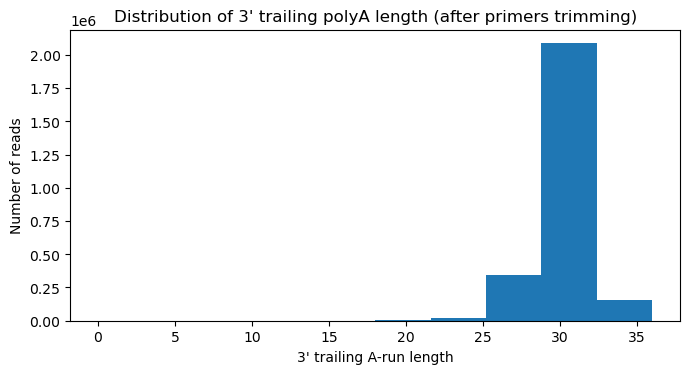

In [ ]:
trailingA_counts = trailingA_df['nA'].to_numpy()

plt.figure(figsize=(7,4))
x_lower = 0; x_higher = np.percentile(trailingA_counts, 99) + 2
plt.hist(trailingA_counts, range=(x_lower, x_higher), density=False)
plt.xlabel("3' trailing A-run length")
plt.ylabel("Number of reads")
plt.title("Distribution of 3' trailing polyA length (after primers trimming)")
plt.tight_layout()
plt.show()

## Map cleaned cDNA reads to reference genome 

Input: FLNC reads  
Output: sorted BAM files
- Run 01_map_sort.sh to map.

## Quality Control

Remove reads with soft clipped ends; low alignment fraction and possible concatemers.

In [ ]:
# Jupyter Notebook Cell 0 — Parameters + sanity checks

import os
import shutil
import subprocess
from pathlib import Path

# -----------------------
# User inputs
# -----------------------
IN_BAM  = Path("syn1.PacBio.FLNC.sorted.bam")          # original mapped BAM
OUT_BAM = Path(HOME_DIR, "syn1.PacBio.FLNC.sorted.HQ.bam")       # final strict HQ BAM

# read-level QC outputs
READ_QC_TSV      = Path("syn1.PacBio.FLNC.read_qc.tsv")
EXCLUDE_QNAME_TXT = Path("syn1.PacBio.FLNC.exclude_concatemer_qnames.txt")
SUMMARY_TXT      = Path("syn1.PacBio.FLNC.qc_summary.txt")

# -----------------------
# Existing mapping thresholds
# -----------------------
MIN_MAPQ      = 20      # raise to 30 for stricter
MIN_ALN_FRAC  = 0.70    # aligned_query_bases / query_length
MAX_CLIP_FRAC = 0.30    # softclip_bases / query_length

# -----------------------
# Structural / concatemer thresholds
# -----------------------
MISMATCH_BP_MIN         = 100
MISMATCH_FRAC_MIN       = 0.15
HIGH_QUERY_COVERAGE_FRAC = 0.80
MULTI_SEG_MIN           = 2
REPEAT_LOCUS_RATIO      = 1.5
DISTANT_GAP_BP          = 200

THREADS    = 8
TMP_PREFIX = f"/tmp/{OUT_BAM.name}.tmp"

def run(cmd, check=True):
    """Run a command and return stdout as string; print stderr if non-empty."""
    print("+", " ".join(map(str, cmd)))
    p = subprocess.run(list(map(str, cmd)), check=check,
                       stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if p.stderr.strip():
        print(p.stderr.strip())
    return p.stdout

assert IN_BAM.exists(), f"Input BAM not found: {IN_BAM}"
assert shutil.which("samtools"), "samtools not found on PATH. Load module or install samtools."

print("IN_BAM :", IN_BAM)
print("OUT_BAM:", OUT_BAM)
print(f"MIN_MAPQ={MIN_MAPQ}  MIN_ALN_FRAC={MIN_ALN_FRAC}  MAX_CLIP_FRAC={MAX_CLIP_FRAC}")
print(f"MISMATCH_BP_MIN={MISMATCH_BP_MIN}  MISMATCH_FRAC_MIN={MISMATCH_FRAC_MIN}")
print(f"HIGH_QUERY_COVERAGE_FRAC={HIGH_QUERY_COVERAGE_FRAC}  MULTI_SEG_MIN={MULTI_SEG_MIN}")
print(f"REPEAT_LOCUS_RATIO={REPEAT_LOCUS_RATIO}  DISTANT_GAP_BP={DISTANT_GAP_BP}")
print(f"THREADS={THREADS}")

IN_BAM : syn1.PacBio.FLNC.sorted.bam
OUT_BAM: /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
MIN_MAPQ=20  MIN_ALN_FRAC=0.7  MAX_CLIP_FRAC=0.3
MISMATCH_BP_MIN=100  MISMATCH_FRAC_MIN=0.15
HIGH_QUERY_COVERAGE_FRAC=0.8  MULTI_SEG_MIN=2
REPEAT_LOCUS_RATIO=1.5  DISTANT_GAP_BP=200
THREADS=8


In [ ]:
# Jupyter Notebook Cell 1 — Helpers

import random
import re
import numpy as np
import pandas as pd
import pysam
from collections import defaultdict

CIGAR_TOKEN_RE = re.compile(r"(\d+)([MIDNSHP=XB])")

def cigar_stats(cigar: str):
    """
    Returns (qlen, alnq, clip) where:
      qlen = sum(M,I,S,=,X)  query-consuming
      alnq = sum(M,I,=,X)    aligned query-consuming (excludes S)
      clip = sum(S)          total softclip (anywhere; usually ends)
    """
    if cigar in ("*", "", None):
        return (0, 0, 0)
    qlen = alnq = clip = 0
    for n_str, op in CIGAR_TOKEN_RE.findall(cigar):
        n = int(n_str)
        if op in ("M", "I", "S", "=", "X"):
            qlen += n
        if op in ("M", "I", "=", "X"):
            alnq += n
        if op == "S":
            clip += n
    return (qlen, alnq, clip)

def first_last_clip_from_cigar_tuples(cigartuples):
    if not cigartuples:
        return 0, 0
    left = cigartuples[0][1] if cigartuples[0][0] in (4, 5) else 0
    right = cigartuples[-1][1] if cigartuples[-1][0] in (4, 5) else 0
    return left, right

def merge_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]

def interval_len(intervals):
    return sum(e - s for s, e in intervals)

def qc_report(bam_path: Path, sample_n: int = 200000, seed: int = 1) -> dict:
    """
    QC summary using:
      - global counts via samtools view -c
      - sampled distributions from primary mapped records (streaming + reservoir sampling)
    """
    bam_path = Path(bam_path)
    assert bam_path.exists(), f"Missing BAM: {bam_path}"
    random.seed(seed)

    total = int(run(["samtools", "view", "-c", str(bam_path)]).strip() or 0)
    mapped = int(run(["samtools", "view", "-c", "-F", "4", str(bam_path)]).strip() or 0)
    unmapped = total - mapped

    # Primary mapped: exclude unmapped(0x4), secondary(0x100), supplementary(0x800) => 2308
    primary_mapped = int(run(["samtools", "view", "-c", "-F", "2308", str(bam_path)]).strip() or 0)
    secondary = int(run(["samtools", "view", "-c", "-f", "256", str(bam_path)]).strip() or 0)
    supplementary = int(run(["samtools", "view", "-c", "-f", "2048", str(bam_path)]).strip() or 0)

    cmd = ["samtools", "view", "-F", "2308", str(bam_path)]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    mapq_vals = []
    alnfrac_vals = []
    clipfrac_vals = []

    seen = 0
    kept = 0

    for line in p.stdout:
        seen += 1

        if kept < sample_n:
            take = True
        else:
            take = (random.random() < (sample_n / float(seen)))
        if not take:
            continue

        fields = line.rstrip("\n").split("\t")
        if len(fields) < 6:
            continue

        mapq = int(fields[4])
        cigar = fields[5]
        qlen, alnq, clip = cigar_stats(cigar)
        if qlen <= 0:
            continue

        alnfrac = alnq / qlen
        clipfrac = clip / qlen

        if kept < sample_n:
            mapq_vals.append(mapq)
            alnfrac_vals.append(alnfrac)
            clipfrac_vals.append(clipfrac)
            kept += 1
        else:
            j = random.randrange(sample_n)
            mapq_vals[j] = mapq
            alnfrac_vals[j] = alnfrac
            clipfrac_vals[j] = clipfrac

    _, stderr = p.communicate()
    if p.returncode != 0:
        raise RuntimeError(f"samtools view failed on {bam_path}:\n{stderr}")

    def summarize(arr):
        if not arr:
            return {"n": 0}
        a = np.asarray(arr, dtype=float)
        return {
            "n": int(a.size),
            "min": float(np.min(a)),
            "p05": float(np.quantile(a, 0.05)),
            "p50": float(np.quantile(a, 0.50)),
            "p95": float(np.quantile(a, 0.95)),
            "max": float(np.max(a)),
            "mean": float(np.mean(a)),
        }

    return {
        "bam": str(bam_path),
        "counts": {
            "total_alignments": total,
            "mapped_alignments": mapped,
            "unmapped_alignments": unmapped,
            "primary_mapped": primary_mapped,
            "secondary": secondary,
            "supplementary": supplementary,
        },
        "sample_n_used": len(mapq_vals),
        "mapq": summarize(mapq_vals),
        "aligned_fraction": summarize(alnfrac_vals),
        "softclip_fraction": summarize(clipfrac_vals),
    }

def print_qc(report: dict, title: str):
    print("=" * 90)
    print(title)
    print("=" * 90)
    c = report["counts"]
    print(f"BAM: {report['bam']}")
    print(f"Total alignments    : {c['total_alignments']:,}")
    print(f"Mapped alignments   : {c['mapped_alignments']:,}")
    print(f"Unmapped alignments : {c['unmapped_alignments']:,}")
    print(f"Primary mapped      : {c['primary_mapped']:,}")
    print(f"Secondary           : {c['secondary']:,}")
    print(f"Supplementary       : {c['supplementary']:,}")
    print(f"Sample used         : {report['sample_n_used']:,} (from primary mapped)")
    for k in ("mapq", "aligned_fraction", "softclip_fraction"):
        s = report[k]
        if s.get("n", 0) == 0:
            print(f"{k:18s}: n=0")
            continue
        print(
            f"{k:18s}: "
            f"min={s['min']:.4g}  p05={s['p05']:.4g}  p50={s['p50']:.4g}  "
            f"p95={s['p95']:.4g}  max={s['max']:.4g}  mean={s['mean']:.4g}"
        )

In [ ]:
# Jupyter Notebook Cell 2 — Build read-level QC table from original BAM
# Uses primary + supplementary structure to identify strong concatemer-like reads

bam = pysam.AlignmentFile(str(IN_BAM), "rb")

read_groups = defaultdict(list)

for aln in bam.fetch(until_eof=True):
    if aln.is_unmapped:
        continue
    if aln.is_secondary:
        continue

    qname = aln.query_name

    qlen = aln.infer_read_length()
    if qlen is None:
        qlen = aln.query_length
    if qlen is None:
        qlen = 0

    chrom = bam.get_reference_name(aln.reference_id)
    strand = "-" if aln.is_reverse else "+"

    ref_start0 = aln.reference_start
    ref_end0 = aln.reference_end if aln.reference_end is not None else aln.reference_start
    ref_span = max(0, ref_end0 - ref_start0)

    qstart = aln.query_alignment_start if aln.query_alignment_start is not None else 0
    qend = aln.query_alignment_end if aln.query_alignment_end is not None else qstart
    q_aln_span = max(0, qend - qstart)

    cigar = aln.cigarstring
    cigartuples = aln.cigartuples or ()
    qlen_cigar, alnq_cigar, clip_cigar = cigar_stats(cigar)
    left_clip, right_clip = first_last_clip_from_cigar_tuples(cigartuples)

    read_groups[qname].append({
        "qname": qname,
        "qlen": qlen,
        "chrom": chrom,
        "strand": strand,
        "ref_start0": ref_start0,
        "ref_end0": ref_end0,
        "ref_span": ref_span,
        "q_aln_start0": qstart,
        "q_aln_end0": qend,
        "q_aln_span": q_aln_span,
        "mapq": aln.mapping_quality,
        "is_primary": int(not aln.is_supplementary),
        "is_supplementary": int(aln.is_supplementary),
        "qlen_cigar": qlen_cigar,
        "alnq_cigar": alnq_cigar,
        "clip_cigar": clip_cigar,
        "left_clip": left_clip,
        "right_clip": right_clip,
    })

bam.close()

rows = []

for qname, segs in read_groups.items():
    segs = sorted(segs, key=lambda x: (x["q_aln_start0"], x["q_aln_end0"]))

    qlen = max(seg["qlen"] for seg in segs) if segs else 0
    n_segments = len(segs)
    n_supplementary = sum(seg["is_supplementary"] for seg in segs)

    primary_segs = [seg for seg in segs if seg["is_primary"] == 1]
    if len(primary_segs) == 0:
        primary = segs[0]
    else:
        primary = sorted(primary_segs, key=lambda x: (x["q_aln_span"], x["mapq"]), reverse=True)[0]

    # Existing per-read mapping QC based on primary alignment only
    primary_mapq = primary["mapq"]
    primary_qlen_cigar = primary["qlen_cigar"]
    primary_alnq_cigar = primary["alnq_cigar"]
    primary_clip_cigar = primary["clip_cigar"]

    if primary_qlen_cigar > 0:
        primary_aln_frac = primary_alnq_cigar / primary_qlen_cigar
        primary_clip_frac = primary_clip_cigar / primary_qlen_cigar
    else:
        primary_aln_frac = np.nan
        primary_clip_frac = np.nan

    fail_mapq = int(primary_mapq < MIN_MAPQ)
    fail_aln_frac = int(pd.isna(primary_aln_frac) or primary_aln_frac < MIN_ALN_FRAC)
    fail_clip_frac = int(pd.isna(primary_clip_frac) or primary_clip_frac > MAX_CLIP_FRAC)
    pass_mapping_qc = int((fail_mapq == 0) and (fail_aln_frac == 0) and (fail_clip_frac == 0))

    # Query coverage across all non-secondary segments
    q_intervals = [(seg["q_aln_start0"], seg["q_aln_end0"])
                   for seg in segs if seg["q_aln_end0"] > seg["q_aln_start0"]]
    q_merged = merge_intervals(q_intervals)
    q_unique_aligned = interval_len(q_merged)
    q_aligned_frac_all = (q_unique_aligned / qlen) if qlen > 0 else np.nan

    # Reference aggregation
    total_ref_span = sum(seg["ref_span"] for seg in segs)
    chrom_strand_set = {(seg["chrom"], seg["strand"]) for seg in segs}
    same_chr_strand_all = (len(chrom_strand_set) == 1)

    if same_chr_strand_all:
        ref_intervals = [(seg["ref_start0"], seg["ref_end0"]) for seg in segs]
        ref_merged = merge_intervals(ref_intervals)
        merged_ref_span_same_locus = interval_len(ref_merged)

        xs = sorted(ref_intervals)
        gaps = [xs[i+1][0] - xs[i][1] for i in range(len(xs)-1)]
        max_ref_gap_same_locus = max(gaps) if gaps else 0

        if merged_ref_span_same_locus > 0:
            repeat_locus_ratio = total_ref_span / merged_ref_span_same_locus
        else:
            repeat_locus_ratio = np.nan
    else:
        merged_ref_span_same_locus = np.nan
        max_ref_gap_same_locus = np.nan
        repeat_locus_ratio = np.nan

    # Mismatch vs primary genomic span
    primary_ref_span = primary["ref_span"]
    mismatch_bp = qlen - primary_ref_span
    mismatch_frac = (mismatch_bp / qlen) if qlen > 0 else np.nan

    has_big_mismatch = int(
        (mismatch_bp >= MISMATCH_BP_MIN) and
        (pd.notna(mismatch_frac) and mismatch_frac >= MISMATCH_FRAC_MIN)
    )

    likely_terminal_clip = int(
        (has_big_mismatch == 1) and
        (n_segments == 1) and
        ((primary["left_clip"] + primary["right_clip"]) >= MISMATCH_BP_MIN)
    )

    likely_multi_segment = int(
        (has_big_mismatch == 1) and
        (n_segments >= MULTI_SEG_MIN) and
        (pd.notna(q_aligned_frac_all) and q_aligned_frac_all >= HIGH_QUERY_COVERAGE_FRAC)
    )

    likely_repeat_same_locus = int(
        (likely_multi_segment == 1) and
        same_chr_strand_all and
        pd.notna(repeat_locus_ratio) and
        (repeat_locus_ratio >= REPEAT_LOCUS_RATIO)
    )

    likely_split_distant = int(
        (likely_multi_segment == 1) and (
            (not same_chr_strand_all) or
            (pd.notna(max_ref_gap_same_locus) and max_ref_gap_same_locus >= DISTANT_GAP_BP)
        )
    )

    likely_concatemer_strong = int(
        (likely_repeat_same_locus == 1) or
        (likely_split_distant == 1)
    )

    if pass_mapping_qc == 0:
        if fail_mapq == 1:
            final_label = "FAIL_MAPQ"
        elif fail_aln_frac == 1:
            final_label = "FAIL_ALN_FRAC"
        elif fail_clip_frac == 1:
            final_label = "FAIL_CLIP_FRAC"
        else:
            final_label = "FAIL_MAPPING_OTHER"
    else:
        if likely_concatemer_strong == 1:
            final_label = "FAIL_CONCATEMER_STRONG"
        elif likely_terminal_clip == 1:
            final_label = "FAIL_TERMINAL_CLIP_STRUCTURE"
        elif has_big_mismatch == 1:
            final_label = "FAIL_AMBIGUOUS_STRUCTURE"
        else:
            final_label = "PASS_STRICT"

    rows.append({
        "qname": qname,
        "qlen": qlen,
        "n_segments": n_segments,
        "n_supplementary": n_supplementary,

        "primary_chrom": primary["chrom"],
        "primary_strand": primary["strand"],
        "primary_ref_start_1b": primary["ref_start0"] + 1,
        "primary_ref_end_1b": primary["ref_end0"],
        "primary_ref_span": primary_ref_span,
        "primary_mapq": primary_mapq,

        "primary_qlen_cigar": primary_qlen_cigar,
        "primary_alnq_cigar": primary_alnq_cigar,
        "primary_clip_cigar": primary_clip_cigar,
        "primary_aln_frac": primary_aln_frac,
        "primary_clip_frac": primary_clip_frac,

        "fail_mapq": fail_mapq,
        "fail_aln_frac": fail_aln_frac,
        "fail_clip_frac": fail_clip_frac,
        "pass_mapping_qc": pass_mapping_qc,

        "q_unique_aligned": q_unique_aligned,
        "q_aligned_frac_all": q_aligned_frac_all,
        "total_ref_span": total_ref_span,
        "merged_ref_span_same_locus": merged_ref_span_same_locus,
        "same_chr_strand_all": int(same_chr_strand_all),
        "repeat_locus_ratio": repeat_locus_ratio,
        "max_ref_gap_same_locus": max_ref_gap_same_locus,

        "mismatch_bp_vs_primary_ref_span": mismatch_bp,
        "mismatch_frac_vs_primary_ref_span": mismatch_frac,
        "has_big_mismatch": has_big_mismatch,
        "likely_terminal_clip": likely_terminal_clip,
        "likely_multi_segment": likely_multi_segment,
        "likely_repeat_same_locus": likely_repeat_same_locus,
        "likely_split_distant": likely_split_distant,
        "likely_concatemer_strong": likely_concatemer_strong,

        "final_label": final_label,
    })

read_qc_df = pd.DataFrame(rows)
read_qc_df.to_csv(READ_QC_TSV, sep="\t", index=False)

exclude_qnames = set(
    read_qc_df.loc[read_qc_df["final_label"] == "FAIL_CONCATEMER_STRONG", "qname"].tolist()
)

with open(EXCLUDE_QNAME_TXT, "w") as f:
    for qn in sorted(exclude_qnames):
        f.write(qn + "\n")

print(f"Wrote read-level QC table: {READ_QC_TSV}")
print(f"Wrote concatemer exclude list: {EXCLUDE_QNAME_TXT}")
print("\nFinal label counts:")
print(read_qc_df["final_label"].value_counts())

Wrote read-level QC table: syn1.PacBio.FLNC.read_qc.tsv
Wrote concatemer exclude list: syn1.PacBio.FLNC.exclude_concatemer_qnames.txt

Final label counts:
final_label
PASS_STRICT                     2612794
FAIL_ALN_FRAC                      4159
FAIL_TERMINAL_CLIP_STRUCTURE       2754
FAIL_MAPQ                          1469
FAIL_AMBIGUOUS_STRUCTURE           1045
FAIL_CONCATEMER_STRONG              236
Name: count, dtype: int64


In [ ]:
# Jupyter Notebook Cell 3 — QC BEFORE filtering

qc_before = qc_report(IN_BAM, sample_n=200000, seed=1)
print_qc(qc_before, "QC BEFORE FILTERING")

+ samtools view -c syn1.PacBio.FLNC.sorted.bam
+ samtools view -c -F 4 syn1.PacBio.FLNC.sorted.bam
+ samtools view -c -F 2308 syn1.PacBio.FLNC.sorted.bam
+ samtools view -c -f 256 syn1.PacBio.FLNC.sorted.bam
+ samtools view -c -f 2048 syn1.PacBio.FLNC.sorted.bam
QC BEFORE FILTERING
BAM: syn1.PacBio.FLNC.sorted.bam
Total alignments    : 2,626,401
Mapped alignments   : 2,625,772
Unmapped alignments : 629
Primary mapped      : 2,622,457
Secondary           : 0
Supplementary       : 3,315
Sample used         : 200,000 (from primary mapped)
mapq              : min=0  p05=60  p50=60  p95=60  max=60  mean=59.97
aligned_fraction  : min=0.3324  p05=0.994  p50=1  p95=1  max=1  mean=0.9974
softclip_fraction : min=0  p05=0  p50=0  p95=0.005994  max=0.6676  mean=0.002608


In [ ]:
# Jupyter Notebook Cell 4 — Filter to HQ BAM
# Keep your original mapping QC, then exclude strong concatemer-like reads by qname

import signal

BASE_FILTER_FLAGS = 2308

# AWK program:
# 1. remove low MAPQ
# 2. remove low aligned fraction
# 3. remove excessive softclip fraction
# 4. remove qnames present in EXCLUDE_QNAME_TXT
awk_prog = r'''
BEGIN {
  OFS="\t"
  while ((getline line < EXCLUDE_FILE) > 0) {
    bad[line] = 1
  }
  close(EXCLUDE_FILE)
}
/^@/ { print; next }
{
  qname = $1
  if (qname in bad) next

  mapq = $5 + 0
  if (mapq < MIN_MAPQ) next

  cigar = $6
  if (cigar == "*" || cigar == "") next

  qlen = 0
  alnq = 0
  clip = 0

  while (match(cigar, /^([0-9]+)([MIDNSHP=XB])/, m)) {
    len = m[1] + 0
    op  = m[2]
    if (op ~ /[MIS=X]/) qlen += len
    if (op ~ /[MI=X]/)  alnq += len
    if (op == "S")      clip += len
    cigar = substr(cigar, RLENGTH + 1)
  }

  if (qlen <= 0) next

  aln_frac  = alnq / qlen
  clip_frac = clip / qlen

  if (aln_frac < MIN_ALN_FRAC) next
  if (clip_frac > MAX_CLIP_FRAC) next

  print
}
'''

cmd_view = ["samtools", "view", "-h", "-F", str(BASE_FILTER_FLAGS), str(IN_BAM)]
cmd_awk  = ["awk",
            f"-vMIN_MAPQ={MIN_MAPQ}",
            f"-vMIN_ALN_FRAC={MIN_ALN_FRAC}",
            f"-vMAX_CLIP_FRAC={MAX_CLIP_FRAC}",
            f"-vEXCLUDE_FILE={str(EXCLUDE_QNAME_TXT)}",
            awk_prog]
cmd_sort = ["samtools", "sort", "-@", str(THREADS), "-T", TMP_PREFIX, "-o", str(OUT_BAM)]

print("[INFO] Running: samtools view | awk | samtools sort")
p_view = subprocess.Popen(cmd_view, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
p_awk  = subprocess.Popen(cmd_awk,  stdin=p_view.stdout, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
p_sort = subprocess.Popen(cmd_sort, stdin=p_awk.stdout, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

p_view.stdout.close()
p_awk.stdout.close()

_, err_sort = p_sort.communicate()
err_awk  = p_awk.stderr.read()
err_view = p_view.stderr.read()
rc_view  = p_view.wait()
rc_awk   = p_awk.wait()
rc_sort  = p_sort.returncode

SIGPIPE_RC = -signal.SIGPIPE

if rc_view not in (0, SIGPIPE_RC):
    raise RuntimeError(f"samtools view failed (rc={rc_view}):\n{err_view}")
if rc_awk not in (0, SIGPIPE_RC):
    raise RuntimeError(f"awk failed (rc={rc_awk}):\n{err_awk}")
if rc_sort != 0:
    raise RuntimeError(f"samtools sort failed (rc={rc_sort}):\n{err_sort}")

run(["samtools", "index", "-@", str(THREADS), str(OUT_BAM)])
print("[DONE] Wrote:", OUT_BAM)
print("[DONE] Index:", str(OUT_BAM) + ".bai")

[INFO] Running: samtools view | awk | samtools sort
+ samtools index -@ 8 /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
[DONE] Wrote: /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
[DONE] Index: /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam.bai


In [ ]:
# Jupyter Notebook Cell 5 — QC AFTER filtering + retention

qc_after = qc_report(OUT_BAM, sample_n=200000, seed=1)
print_qc(qc_after, "QC AFTER FILTERING")

before_primary = qc_before["counts"]["primary_mapped"]
after_primary  = qc_after["counts"]["primary_mapped"]
ret = (after_primary / before_primary) if before_primary else float("nan")
print("\nRetention (primary mapped): {:.2%}".format(ret))

+ samtools view -c /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
+ samtools view -c -F 4 /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
+ samtools view -c -F 2308 /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
+ samtools view -c -f 256 /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
+ samtools view -c -f 2048 /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
QC AFTER FILTERING
BAM: /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam
Total alignments    : 2,616,593
Mapped alignments   : 2,616,593
Unmapped alignments : 0
Primary mapped      : 2,616,593
Secondary           : 0
Supplementary       : 0
Sample used         : 200,000 (from primary mapped)
mapq              : m

In [ ]:
# Jupyter Notebook Cell 6 — Summary of removal reasons

label_counts = read_qc_df["final_label"].value_counts().sort_index()
total_reads = len(read_qc_df)

summary_lines = []
summary_lines.append(f"Input BAM: {IN_BAM}")
summary_lines.append(f"Output BAM: {OUT_BAM}")
summary_lines.append("")
summary_lines.append("Thresholds:")
summary_lines.append(f"  MIN_MAPQ={MIN_MAPQ}")
summary_lines.append(f"  MIN_ALN_FRAC={MIN_ALN_FRAC}")
summary_lines.append(f"  MAX_CLIP_FRAC={MAX_CLIP_FRAC}")
summary_lines.append(f"  MISMATCH_BP_MIN={MISMATCH_BP_MIN}")
summary_lines.append(f"  MISMATCH_FRAC_MIN={MISMATCH_FRAC_MIN}")
summary_lines.append(f"  HIGH_QUERY_COVERAGE_FRAC={HIGH_QUERY_COVERAGE_FRAC}")
summary_lines.append(f"  MULTI_SEG_MIN={MULTI_SEG_MIN}")
summary_lines.append(f"  REPEAT_LOCUS_RATIO={REPEAT_LOCUS_RATIO}")
summary_lines.append(f"  DISTANT_GAP_BP={DISTANT_GAP_BP}")
summary_lines.append("")
summary_lines.append(f"Total reads in read-level QC table: {total_reads:,}")
summary_lines.append("")

for label, count in label_counts.items():
    frac = 100.0 * count / total_reads if total_reads else 0.0
    summary_lines.append(f"{label:30s} : {count:>10,}  ({frac:6.3f}%)")

summary_lines.append("")
summary_lines.append(f"Strong concatemer-like qnames excluded from HQ BAM: {len(exclude_qnames):,}")
summary_lines.append(f"HQ BAM retention among primary mapped alignments: {ret:.4%}")

with open(SUMMARY_TXT, "w") as f:
    f.write("\n".join(summary_lines) + "\n")

print("\n".join(summary_lines))
print(f"\nWrote summary: {SUMMARY_TXT}")

Input BAM: syn1.PacBio.FLNC.sorted.bam
Output BAM: /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/syn1.PacBio.FLNC.sorted.HQ.bam

Thresholds:
  MIN_MAPQ=20
  MIN_ALN_FRAC=0.7
  MAX_CLIP_FRAC=0.3
  MISMATCH_BP_MIN=100
  MISMATCH_FRAC_MIN=0.15
  HIGH_QUERY_COVERAGE_FRAC=0.8
  MULTI_SEG_MIN=2
  REPEAT_LOCUS_RATIO=1.5
  DISTANT_GAP_BP=200

Total reads in read-level QC table: 2,622,457

FAIL_ALN_FRAC                  :      4,159  ( 0.159%)
FAIL_AMBIGUOUS_STRUCTURE       :      1,045  ( 0.040%)
FAIL_CONCATEMER_STRONG         :        236  ( 0.009%)
FAIL_MAPQ                      :      1,469  ( 0.056%)
FAIL_TERMINAL_CLIP_STRUCTURE   :      2,754  ( 0.105%)
PASS_STRICT                    :  2,612,794  (99.632%)

Strong concatemer-like qnames excluded from HQ BAM: 236
HQ BAM retention among primary mapped alignments: 99.7764%

Wrote summary: syn1.PacBio.FLNC.qc_summary.txt


### Report on QC afterwards

In [ ]:
import pandas as pd
import numpy as np

# ----------------------------
# Load
# ----------------------------
df = pd.read_csv("syn1.PacBio.FLNC.read_qc.tsv", sep="\t")

# ----------------------------
# Keep only strict reads
# ----------------------------
df_pass = df[df["final_label"] == "PASS_STRICT"].copy()

print(f"Total reads: {len(df):,}")
print(f"PASS_STRICT reads: {len(df_pass):,} ({len(df_pass)/len(df)*100:.4f}%)")

# ----------------------------
# Derived metrics
# ----------------------------
df_pass["mismatch_bp"] = df_pass["qlen"] - df_pass["primary_ref_span"]
df_pass["mismatch_frac"] = df_pass["mismatch_bp"] / df_pass["qlen"]

# ----------------------------
# Helper summary function
# ----------------------------
def summarize(arr):
    a = np.asarray(arr)
    return {
        "min": float(np.min(a)),
        "p01": float(np.quantile(a, 0.01)),
        "p05": float(np.quantile(a, 0.05)),
        "p50": float(np.quantile(a, 0.50)),
        "p95": float(np.quantile(a, 0.95)),
        "p99": float(np.quantile(a, 0.99)),
        "max": float(np.max(a)),
        "mean": float(np.mean(a)),
    }

# ----------------------------
# Print summaries
# ----------------------------
print("\n=== Read length (qlen) ===")
print(summarize(df_pass["qlen"]))

print("\n=== Primary mapped span ===")
print(summarize(df_pass["primary_ref_span"]))

print("\n=== Mismatch (bp) ===")
print(summarize(df_pass["mismatch_bp"]))

print("\n=== Mismatch fraction ===")
print(summarize(df_pass["mismatch_frac"]))

# ----------------------------
# Alignment quality metrics (primary)
# ----------------------------
print("\n=== Primary alignment fraction ===")
print(summarize(df_pass["primary_aln_frac"]))

print("\n=== Primary clip fraction ===")
print(summarize(df_pass["primary_clip_frac"]))

# ----------------------------
# How tight is the agreement?
# ----------------------------
within_10bp = (df_pass["mismatch_bp"].abs() <= 10).mean()
within_50bp = (df_pass["mismatch_bp"].abs() <= 50).mean()
within_100bp = (df_pass["mismatch_bp"].abs() <= 100).mean()

print("\n=== Agreement metrics ===")
print(f"|mismatch| <= 10 bp  : {within_10bp*100:.2f}%")
print(f"|mismatch| <= 50 bp  : {within_50bp*100:.2f}%")
print(f"|mismatch| <= 100 bp : {within_100bp*100:.2f}%")

Total reads: 2,622,457
PASS_STRICT reads: 2,612,794 (99.6315%)

=== Read length (qlen) ===
{'min': 204.0, 'p01': 677.0, 'p05': 883.0, 'p50': 1561.0, 'p95': 3065.0, 'p99': 3929.0, 'max': 10872.0, 'mean': 1737.9928880730743}

=== Primary mapped span ===
{'min': 202.0, 'p01': 675.0, 'p05': 881.0, 'p50': 1559.0, 'p95': 3066.0, 'p99': 3938.0, 'max': 10869.0, 'mean': 1736.3185111417126}

=== Mismatch (bp) ===
{'min': -5544.0, 'p01': -2.0, 'p05': -1.0, 'p50': 0.0, 'p95': 10.0, 'p99': 55.0, 'max': 904.0, 'mean': 1.6743769313616}

=== Mismatch fraction ===
{'min': -2.930089102124743, 'p01': -0.0013786764705882354, 'p05': -0.0005282620179609086, 'p50': 0.0, 'p95': 0.006111535523300229, 'p99': 0.03985243019812165, 'max': 0.2978723404255319, 'mean': 0.0013483959060024452}

=== Primary alignment fraction ===
{'min': 0.7021276595744681, 'p01': 0.9604987962437173, 'p05': 0.9947245017584996, 'p50': 1.0, 'p95': 1.0, 'p99': 1.0, 'max': 1.0, 'mean': 0.99844216009718}

=== Primary clip fraction ===
{'min'

## Sequencing depth

Run 02_sequencing_depth.sh for following quantification

## IGNORE: Transcriptome Assembly using StringTie

Tried using the ready StringTie software to do the transcriptome assembly but get only monocistronic transcripts.

StringTie dedicated for eukaryotic splicing.

Decided to do custome algorithms to handle bacterial operons.

### Generate GTF (Gene Transfer File) as reference annotation.

In [ ]:
# # User inputs
# GENBANK = "../gene_info/genbank_files/syn1.gb"  # or .gb
# BAM     = "syn1.PacBio.FLNC.sorted.bam"
# a
# GUIDE_GTF = "syn1.stringtie.guide.gtf"
# OUT_PREFIX = "syn1.stringtie.v3"

# THREADS = 16

# from Bio import SeqIO

# records = list(SeqIO.parse(GENBANK, "genbank"))
# if not records:
#     raise RuntimeError("No GenBank records parsed.")

# print("GenBank records:")
# for r in records:
#     print("  record.id:", r.id, "| record.name:", r.name, "| len:", len(r.seq))

# cmd = ["samtools", "idxstats", BAM]
# p = subprocess.run(cmd, check=True, capture_output=True, text=True)
# bam_refs = [line.split("\t")[0] for line in p.stdout.strip().splitlines() if line]
# print("First 10 BAM references:", bam_refs[:10])
# print("Total BAM references:", len(bam_refs))

# gb_ids = set(r.id for r in records)
# common = gb_ids.intersection(bam_refs)
# print("Common GenBank<->BAM contig IDs:", common)

# if not common:
#     print("\nWARNING: No shared contig ID between GenBank and BAM.")
#     print("This usually means BAM uses CP002027.1 but GenBank record.id is CP002027 (or vice versa).")
#     print("We will handle this in the GTF generator by allowing an override if needed.")


In [ ]:
# from Bio import SeqIO

# def pick_id(qualifiers: dict, fallback: str) -> str:
#     # Prefer locus_tag (stable), then gene name, then protein_id, else fallback
#     for k in ("locus_tag", "gene", "protein_id"):
#         if k in qualifiers and qualifiers[k]:
#             return str(qualifiers[k][0]).strip()
#     return fallback

# def feature_span_1based(feat):
#     # Biopython: 0-based, end-exclusive. Convert to 1-based inclusive.
#     start0 = int(feat.location.start)
#     end0   = int(feat.location.end)
#     start = start0 + 1
#     end   = end0
#     strand = feat.location.strand
#     if strand == 1:
#         s = "+"
#     elif strand == -1:
#         s = "-"
#     else:
#         s = "."
#     if start > end:
#         start, end = end, start
#     return start, end, s

# def genbank_to_guide_gtf(genbank_path: str, out_gtf: str, seqid_override: str | None = None):
#     recs = list(SeqIO.parse(genbank_path, "genbank"))
#     if not recs:
#         raise RuntimeError(f"No records parsed from {genbank_path}")

#     used_gene_ids = set()
#     n_genes = 0

#     with open(out_gtf, "w") as out:
#         for rec in recs:
#             seqid = seqid_override if seqid_override else rec.id

#             for feat in rec.features:
#                 if feat.type != "gene":
#                     continue

#                 n_genes += 1
#                 gid = pick_id(feat.qualifiers, fallback=f"gene_{n_genes}")

#                 # ensure uniqueness
#                 base = gid
#                 k = 1
#                 while gid in used_gene_ids:
#                     k += 1
#                     gid = f"{base}_{k}"
#                 used_gene_ids.add(gid)

#                 tid = f"{gid}.t1"
#                 start, end, strand = feature_span_1based(feat)

#                 # transcript
#                 out.write(
#                     f"{seqid}\tguide\ttranscript\t{start}\t{end}\t.\t{strand}\t.\t"
#                     f'gene_id "{gid}"; transcript_id "{tid}";\n'
#                 )
#                 # exon
#                 out.write(
#                     f"{seqid}\tguide\texon\t{start}\t{end}\t.\t{strand}\t.\t"
#                     f'gene_id "{gid}"; transcript_id "{tid}"; exon_number "1";\n'
#                 )

#     return n_genes

# # If contig IDs don't match, you can force seqid_override="CP002027.1" (or whatever your BAM uses).
# # We'll choose an override only if needed.
# seqid_override = None
# if bam_refs:
#     # if BAM has exactly one primary contig like CP002027.1, and GenBank has one record, use BAM's contig
#     # ONLY when there is a mismatch.
#     gb_id = records[0].id
#     if gb_id not in bam_refs and len(bam_refs) >= 1:
#         # pick the first reference that looks like CP002027 or CP002027.1
#         for r in bam_refs:
#             if r.startswith("CP002027"):
#                 seqid_override = r
#                 break

# n_genes = genbank_to_guide_gtf(GENBANK, GUIDE_GTF, seqid_override=seqid_override)
# print(f"Wrote {GUIDE_GTF} with {n_genes} genes.")
# if seqid_override:
#     print(f"Used seqid_override={seqid_override} to match BAM contig naming.")


In [ ]:
# # show first few lines
# with open(GUIDE_GTF, "r") as f:
#     for i in range(6):
#         print(f.readline().rstrip())

# gtf_seqids = set()
# with open(GUIDE_GTF, "r") as f:
#     for line in f:
#         if line.strip():
#             gtf_seqids.add(line.split("\t")[0])
#             if len(gtf_seqids) > 5:
#                 break

# print("Guide GTF seqid(s) (first few):", list(gtf_seqids)[:5])
# print("Any overlap with BAM refs?:", bool(set(gtf_seqids).intersection(set(bam_refs))))
